# Treasury Curve Fit And Moves

This notebook builds synthetic Treasury bond quotes from one hidden yield curve. The observed prices include curve value, small regressor effects, and price noise.

The fitter only sees bond prices and two quote-level regressors: liquidity and specialness. The hidden curve and true coefficients are used only to score the fit.


In [13]:
from decimal import Decimal
from math import exp

from IPython import get_ipython
from IPython.display import display
import matplotlib
import numpy as np
import pandas as pd

from fuggers_py import Currency, Date, Frequency, YieldCalculationRules
from fuggers_py.bonds import BondPricer, BondQuote, FixedBond
from fuggers_py.curves import CurveSpec, STANDARD_KEY_RATE_TENORS, YieldCurve

ipython = get_ipython()
if ipython is None:
    matplotlib.use("Agg")
else:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

def show_figure(fig):
    if ipython is not None:
        display(fig)
    plt.close(fig)


pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic Treasury Quotes

The hidden curve is smooth and upward sloping. Each bond price starts as the present value of its cash flows on that curve, then gets a small liquidity effect, a small specialness effect, and quote noise.


In [14]:
REFERENCE_DATE = Date.from_ymd(2026, 4, 17)
MATURITIES = (1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30)
PRICE_NOISE = (-0.015, 0.010, -0.012, 0.006, 0.014, -0.008, 0.011, -0.006, 0.012, -0.010, 0.005, -0.008, 0.006, -0.007)
LIQUIDITY = (0.16, -0.10, 0.07, -0.15, 0.18, -0.02, -0.13, 0.09, 0.20, -0.08, 0.04, -0.17, 0.05, 0.11)
SPECIALNESS = (-0.12, 0.48, -0.14, -0.10, 0.43, -0.08, -0.11, -0.09, 0.50, -0.13, -0.07, -0.15, -0.05, 0.48)
TRUE_LIQUIDITY_COEF = 0.22
TRUE_SPECIALNESS_COEF = 0.14


def true_zero_rate(t: float) -> float:
    return 0.031 + 0.010 * (1.0 - exp(-t / 7.0)) + 0.0015 * exp(-((t - 10.0) / 6.0) ** 2)


def true_clean_price(bond: FixedBond) -> Decimal:
    value = Decimal("0")
    for cash_flow in bond.cash_flows(REFERENCE_DATE):
        t = max(1e-8, REFERENCE_DATE.days_between(cash_flow.date) / 365.0)
        value += cash_flow.factored_amount() * Decimal(str(exp(-true_zero_rate(t) * t)))
    return value


In [15]:
quotes = []
quote_rows = []

for index, (years, noise, liquidity, specialness) in enumerate(
    zip(MATURITIES, PRICE_NOISE, LIQUIDITY, SPECIALNESS, strict=True),
    start=1,
):
    coupon = Decimal(str(round(true_zero_rate(float(years)) + 0.001 * ((index % 3) - 1), 4)))
    bond = FixedBond.new(
        issue_date=REFERENCE_DATE,
        maturity_date=REFERENCE_DATE.add_years(years),
        coupon_rate=coupon,
        frequency=Frequency.SEMI_ANNUAL,
        currency=Currency.USD,
        rules=YieldCalculationRules.us_treasury(),
        instrument_id=f"UST{years}Y",
    )

    curve_clean = true_clean_price(bond)
    regressor_effect = TRUE_LIQUIDITY_COEF * liquidity + TRUE_SPECIALNESS_COEF * specialness
    clean_price = curve_clean + Decimal(str(regressor_effect + noise))

    quotes.append(
        BondQuote(
            instrument=bond,
            clean_price=clean_price,
            as_of=REFERENCE_DATE,
            regressors={"liquidity": liquidity, "specialness": specialness},
            fit_weight=1.0,
        )
    )
    quote_rows.append(
        {
            "bond": str(bond.instrument_id),
            "years": years,
            "coupon": float(coupon),
            "curve_clean": float(curve_clean),
            "regressor_effect": regressor_effect,
            "price_noise": noise,
            "clean_price": float(clean_price),
            "liquidity": liquidity,
            "specialness": specialness,
        }
    )

quote_table = pd.DataFrame(quote_rows)
quote_table


,bond,years,coupon,curve_clean,regressor_effect,price_noise,clean_price,liquidity,specialness
0,UST1Y,1,0.032500,99.957108,0.018400,-0.015000,99.960508,0.160000,-0.120000
1,UST2Y,2,0.034700,100.124371,0.045200,0.010000,100.179571,-0.100000,0.480000
2,UST3Y,3,0.033900,99.645239,-0.004200,-0.012000,99.629039,0.070000,-0.140000
3,UST4Y,4,0.035900,99.905349,-0.047000,0.006000,99.864349,-0.150000,-0.100000
4,UST5Y,5,0.037900,100.379821,0.099800,0.014000,100.493621,0.180000,0.430000
5,UST6Y,6,0.036700,99.339874,-0.015600,-0.008000,99.316274,-0.020000,-0.080000
6,UST7Y,7,0.038500,99.918913,-0.044000,0.011000,99.885913,-0.130000,-0.110000
7,UST8Y,8,0.040200,100.666614,0.007200,-0.006000,100.667814,0.090000,-0.090000
8,UST10Y,10,0.039100,99.171279,0.114000,0.012000,99.297279,0.200000,0.500000
9,UST12Y,12,0.040500,99.968538,-0.035800,-0.010000,99.922738,-0.080000,-0.130000


## 2. Fit The Curves

Start with the normal user path: pass quotes and a `CurveSpec`, and let `YieldCurve.fit(...)` use its defaults. Then compare two cubic-spline fits: one ignores regressors, and one uses liquidity and specialness.


In [16]:
curve_spec = CurveSpec(
    name="Synthetic Treasury Curve",
    reference_date=REFERENCE_DATE,
    day_count="ACT/365F",
    currency="USD",
    type="nominal",
    extrapolation_policy="hold_last_zero_rate",
)
clean_knots = (1.0, 2.0, 4.0, 7.0, 12.0, 20.0, 31.0)

default_curve = YieldCurve.fit(quotes, spec=curve_spec)
default_report = default_curve.calibration_report

spline_no_regressors = YieldCurve.fit(
    quotes,
    spec=curve_spec,
    kernel="cubic_spline",
    method="global_fit",
    bond_target="clean_price",
    kernel_params={"knots": clean_knots},
)
spline_no_regressors_report = spline_no_regressors.calibration_report

spline_curve = YieldCurve.fit(
    quotes,
    spec=curve_spec,
    kernel="cubic_spline",
    method="global_fit",
    bond_target="clean_price",
    regressors=("liquidity", "specialness"),
    kernel_params={"knots": clean_knots},
)

curve = spline_curve
report = curve.calibration_report
summary = pd.DataFrame(
    [
        {"curve": "default", "method": default_report.method, "kernel": default_report.kernel, "iterations": default_report.iterations, "max_abs_residual": default_report.max_abs_residual},
        {"curve": "spline, no regressors", "method": spline_no_regressors_report.method, "kernel": spline_no_regressors_report.kernel, "iterations": spline_no_regressors_report.iterations, "max_abs_residual": spline_no_regressors_report.max_abs_residual},
        {"curve": "spline + regressors", "method": report.method, "kernel": report.kernel, "iterations": report.iterations, "max_abs_residual": report.max_abs_residual},
    ]
)
summary


,curve,method,kernel,iterations,max_abs_residual
0,default,bootstrap,NaN,28,0.000000
1,"spline, no regressors",global_fit,cubic_spline,4,0.133380
2,spline + regressors,global_fit,cubic_spline,4,0.087534


In [17]:
regressor_fit = pd.DataFrame(
    {
        "regressor": report.regressors,
        "true_price_coefficient": (TRUE_LIQUIDITY_COEF, TRUE_SPECIALNESS_COEF),
        "fitted_price_coefficient": report.regressor_coefficients,
    }
)
regressor_fit["coefficient_error"] = regressor_fit["fitted_price_coefficient"] - regressor_fit["true_price_coefficient"]
regressor_fit


,regressor,true_price_coefficient,fitted_price_coefficient,coefficient_error
0,liquidity,0.220000,0.151244,-0.068756
1,specialness,0.140000,0.151438,0.011438


## 3. Curve Shape And Fit Diagnostics

The default fit shows the common one-line path. The no-regressor spline shows what happens when price effects are forced into the curve. The regressor spline is the richer research fit used below.


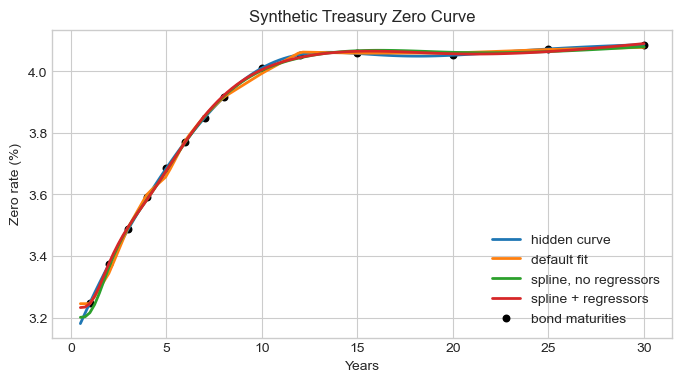

In [18]:
tenor_grid = np.linspace(0.5, 30.0, 120)
curve_plot = pd.DataFrame(
    {
        "years": tenor_grid,
        "true_zero": [true_zero_rate(float(t)) for t in tenor_grid],
        "default_zero": [default_curve.zero_rate_at(float(t)) for t in tenor_grid],
        "spline_no_regressors_zero": [spline_no_regressors.zero_rate_at(float(t)) for t in tenor_grid],
        "spline_zero": [curve.zero_rate_at(float(t)) for t in tenor_grid],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_plot["years"], curve_plot["true_zero"] * 100, label="hidden curve", linewidth=2)
ax.plot(curve_plot["years"], curve_plot["default_zero"] * 100, label="default fit", linewidth=2)
ax.plot(curve_plot["years"], curve_plot["spline_no_regressors_zero"] * 100, label="spline, no regressors", linewidth=2)
ax.plot(curve_plot["years"], curve_plot["spline_zero"] * 100, label="spline + regressors", linewidth=2)
ax.scatter(quote_table["years"], [true_zero_rate(float(t)) * 100 for t in quote_table["years"]], color="black", s=22, label="bond maturities")
ax.set(title="Synthetic Treasury Zero Curve", xlabel="Years", ylabel="Zero rate (%)")
ax.legend()
show_figure(fig)


The hidden curve is not used by the fitter. It is used here only to score the three fits.


In [19]:
curve_recovery = pd.DataFrame(
    [
        {
            "fit": label,
            "mean_abs_zero_error_bp": float(np.mean(np.abs((curve_plot[column] - curve_plot["true_zero"]) * 10_000))),
            "max_abs_zero_error_bp": float(np.max(np.abs((curve_plot[column] - curve_plot["true_zero"]) * 10_000))),
        }
        for label, column in [
            ("default", "default_zero"),
            ("spline, no regressors", "spline_no_regressors_zero"),
            ("spline + regressors", "spline_zero"),
        ]
    ]
)
curve_recovery


,fit,mean_abs_zero_error_bp,max_abs_zero_error_bp
0,default,0.780409,6.453014
1,"spline, no regressors",0.847052,3.777564
2,spline + regressors,0.667059,5.198496


In [20]:
fit_points = pd.DataFrame(
    [
        {
            "bond": point.instrument_id,
            "years": point.tenor,
            "observed_clean": point.observed_value,
            "fitted_clean": point.fitted_value,
            "price_residual": point.residual,
            "curve_only_clean": point.curve_only_value,
            "regressor_effect": point.regressor_contribution,
            "curve_only_ytm_residual_bp": point.ytm_bp_residual,
        }
        for point in report.points
    ]
)
fit_points

,bond,years,observed_clean,fitted_clean,price_residual,curve_only_clean,regressor_effect,curve_only_ytm_residual_bp
0,UST1Y,1.005479,99.960508,99.965540,0.005032,99.959514,0.006027,0.101910
1,UST2Y,2.002740,100.179571,100.175859,-0.003712,100.118293,0.057566,3.191894
2,UST3Y,3.002740,99.629039,99.613732,-0.015307,99.624346,-0.010614,0.166567
3,UST4Y,4.002740,99.864349,99.887438,0.023089,99.925268,-0.037830,-1.650577
4,UST5Y,5.002740,100.493621,100.505078,0.011456,100.412735,0.092342,1.781682
5,UST6Y,6.010959,99.316274,99.328049,0.011775,99.343189,-0.015140,-0.507802
6,UST7Y,7.008219,99.885913,99.849359,-0.036554,99.885679,-0.036320,0.003859
7,UST8Y,8.005479,100.667814,100.631113,-0.036701,100.631131,-0.000017,0.536707
8,UST10Y,10.008219,99.297279,99.312523,0.015244,99.206556,0.105968,1.114676
9,UST12Y,12.013699,99.922738,100.010272,0.087534,100.042058,-0.031786,-1.265567


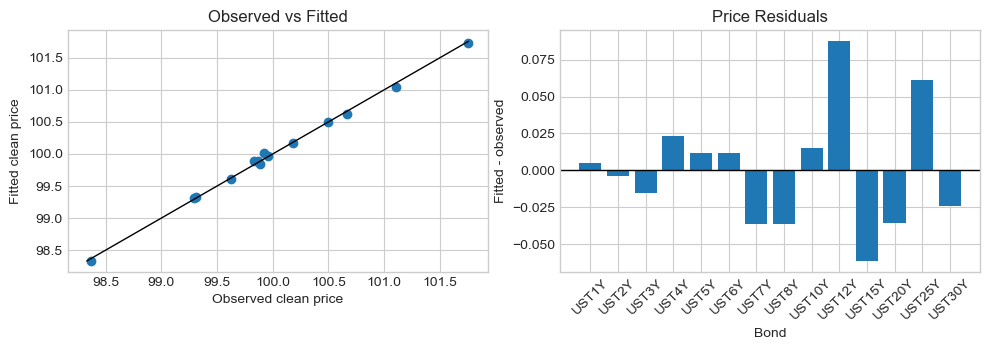

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(fit_points["observed_clean"], fit_points["fitted_clean"])
line_min = min(fit_points["observed_clean"].min(), fit_points["fitted_clean"].min())
line_max = max(fit_points["observed_clean"].max(), fit_points["fitted_clean"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color="black", linewidth=1)
axes[0].set(title="Observed vs Fitted", xlabel="Observed clean price", ylabel="Fitted clean price")

axes[1].bar(fit_points["bond"], fit_points["price_residual"])
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set(title="Price Residuals", xlabel="Bond", ylabel="Fitted - observed")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
show_figure(fig)

## 4. Use The Fitted Curve

A fitted `YieldCurve` is also a `DiscountingCurve`. That means it can return zero rates, discount factors, forward rates, and date-based values.

In [22]:
def years_from_reference(date: Date) -> float:
    return REFERENCE_DATE.days_between(date) / 365.0


future_date = REFERENCE_DATE.add_years(7)
start_date = REFERENCE_DATE.add_years(2)
end_date = REFERENCE_DATE.add_years(10)
future_t = years_from_reference(future_date)
start_t = years_from_reference(start_date)
end_t = years_from_reference(end_date)

curve_queries = pd.DataFrame(
    [
        {"query": "2Y zero rate", "value": curve.zero_rate_at(2.0)},
        {"query": "10Y discount factor", "value": curve.discount_factor_at(10.0)},
        {"query": "2Y-10Y forward rate", "value": curve.forward_rate_between(2.0, 10.0)},
        {"query": f"zero rate at {future_date}", "value": curve.zero_rate_at(future_t)},
        {"query": f"discount factor at {future_date}", "value": curve.discount_factor_at(future_t)},
        {"query": f"forward rate {start_date} to {end_date}", "value": curve.forward_rate_between(start_t, end_t)},
    ]
)
curve_queries

,query,value
0,2Y zero rate,0.033769
1,10Y discount factor,0.669985
2,2Y-10Y forward rate,0.041620
3,zero rate at 2033-04-17,0.038555
4,discount factor at 2033-04-17,0.763304
5,forward rate 2028-04-17 to 2036-04-17,0.041623


## 5. Move The Curve And Reprice The Same Bonds

`shifted(...)` moves every zero rate by the same amount. `bumped(...)` moves selected tenors and interpolates the move between grid points.

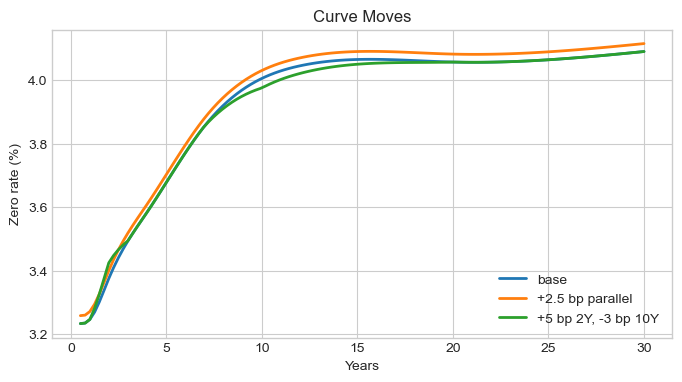

In [23]:
parallel_up = curve.shifted(shift=0.00025)
key_bumped = curve.bumped(
    tenor_grid=STANDARD_KEY_RATE_TENORS,
    bumps={
        2.0: 0.00050,
        10.0: -0.00030,
    },
)

move_plot = pd.DataFrame(
    {
        "years": tenor_grid,
        "base": [curve.zero_rate_at(float(t)) for t in tenor_grid],
        "parallel_up": [parallel_up.zero_rate_at(float(t)) for t in tenor_grid],
        "key_bumped": [key_bumped.zero_rate_at(float(t)) for t in tenor_grid],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
for column, label in [("base", "base"), ("parallel_up", "+2.5 bp parallel"), ("key_bumped", "+5 bp 2Y, -3 bp 10Y")]:
    ax.plot(move_plot["years"], move_plot[column] * 100, label=label, linewidth=2)
ax.set(title="Curve Moves", xlabel="Years", ylabel="Zero rate (%)")
ax.legend()
show_figure(fig)

In [24]:
pricer = BondPricer()
scenario_rows = []

for quote in quotes:
    bond = quote.instrument
    base_price = pricer.price_from_curve(bond, curve, REFERENCE_DATE).dirty.as_percentage()
    parallel_price = pricer.price_from_curve(bond, parallel_up, REFERENCE_DATE).dirty.as_percentage()
    key_bumped_price = pricer.price_from_curve(bond, key_bumped, REFERENCE_DATE).dirty.as_percentage()
    scenario_rows.append(
        {
            "bond": str(bond.instrument_id),
            "years": REFERENCE_DATE.days_between(bond.maturity_date()) / 365.0,
            "base_dirty": base_price,
            "parallel_change": parallel_price - base_price,
            "key_bump_change": key_bumped_price - base_price,
        }
    )

scenario_table = pd.DataFrame(scenario_rows)
scenario_table

,bond,years,base_dirty,parallel_change,key_bump_change
0,UST1Y,1.000000,99.959513808460750250000,-0.024924413091032975000,-0.000270958228175175000
1,UST2Y,2.002740,100.118293339974513544500,-0.048852858699504244500,-0.095533708096477792500
2,UST3Y,3.002740,99.624346290136704980500,-0.071706274501300876500,-0.003162227942624160000
3,UST4Y,4.002740,99.925268219391138489500,-0.093978294660064460500,-0.003348790063132960000
4,UST5Y,5.002740,100.412735435509219711500,-0.115503841567051783500,-0.003535352183641760000
5,UST6Y,6.005479,99.343189276513517735000,-0.135103239201065247000,-0.003423414911336480000
6,UST7Y,7.005479,99.885678893209415085000,-0.154777363051498422500,-0.003143232797155422500
7,UST8Y,8.005479,100.631130776785523905000,-0.173928077242181681000,0.056842230142954340000
8,UST10Y,10.008219,99.206555594743769245000,-0.206954997706453958000,0.210683450387984255000
9,UST12Y,12.008219,100.042058267243945387500,-0.239922441615790770000,0.202270221509733677500


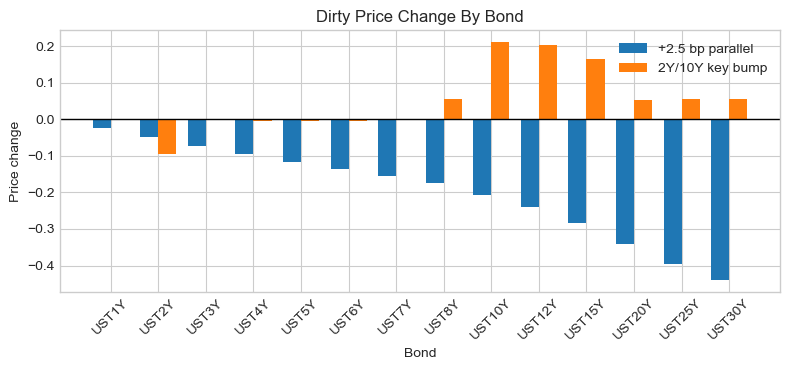

In [25]:
fig, ax = plt.subplots(figsize=(8, 3.8))
width = 0.38
x = np.arange(len(scenario_table))
ax.bar(x - width / 2, scenario_table["parallel_change"], width=width, label="+2.5 bp parallel")
ax.bar(x + width / 2, scenario_table["key_bump_change"], width=width, label="2Y/10Y key bump")
ax.axhline(0.0, color="black", linewidth=1)
ax.set(title="Dirty Price Change By Bond", xlabel="Bond", ylabel="Price change")
ax.set_xticks(x, scenario_table["bond"], rotation=45)
ax.legend()
plt.tight_layout()
show_figure(fig)